# 정신 건강 치료 결정 예측 모델링

업무 환경 관련 설문 응답을 이용해 treatment를 분류하는 모델

## 사용 모델
Logistic Regression, Decision Tree, KNN, Bagging, Random Forest, AdaBoost, Gradient Boosting

## 노트북 흐름
전처리 -> 모델 학습 -> 교차 검증 결과 시각화 -> 모델별 permutation feature importance를 순서대로 확인


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier


In [11]:
def clean_gender(value):
    gender = str(value).strip().lower()

    male_values = [
        "male", "m", "male-ish", "maile", "mal", "male (cis)",
        "make", "male ", "man", "msle", "mail", "cis male",
        "cis man", "ostensibly male, unsure what that really means"
    ]

    female_values = [
        "female", "f", "woman", "female ", "femake",
        "female (cis)", "cis female", "femail"
    ]

    if gender in male_values:
        return "Male"
    if gender in female_values:
        return "Female"
    return "Other"


def drop_unnecessary_columns(df_clean):
    drop_columns = ["Timestamp", "comments", "state"]
    existing_drop_columns = [col for col in drop_columns if col in df_clean.columns]
    return df_clean.drop(columns=existing_drop_columns)


def handle_dirty_age(df_clean):
    if "Age" not in df_clean.columns:
        return df_clean

    df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")
    invalid_age = (df_clean["Age"] < 18) | (df_clean["Age"] > 80)
    df_clean.loc[invalid_age, "Age"] = np.nan
    age_median = df_clean["Age"].median()
    df_clean["Age"] = df_clean["Age"].fillna(age_median)
    return df_clean


def handle_dirty_gender(df_clean):
    if "Gender" in df_clean.columns:
        df_clean["Gender"] = df_clean["Gender"].apply(clean_gender)
    return df_clean


def handle_missing_values(df_clean):
    if "self_employed" in df_clean.columns:
        self_employed_mode = df_clean["self_employed"].mode()[0]
        df_clean["self_employed"] = df_clean["self_employed"].fillna(self_employed_mode)

    if "work_interfere" in df_clean.columns:
        work_interfere_mode = df_clean["work_interfere"].mode()[0]
        df_clean["work_interfere"] = df_clean["work_interfere"].fillna(work_interfere_mode)

    return df_clean


In [12]:
def encode_target_variable(df_clean, target_col="treatment"):
    df_clean[target_col] = df_clean[target_col].map({"Yes": 1, "No": 0})
    return df_clean


def convert_country_to_continent(df_clean):
    if "Country" not in df_clean.columns:
        return df_clean

    continent_map = {
        "United States": "North America", "Canada": "North America",
        "Mexico": "North America", "Costa Rica": "North America",
        "Bahamas, The": "North America", "Brazil": "South America",
        "Colombia": "South America", "Uruguay": "South America",
        "Austria": "Europe", "Belgium": "Europe",
        "Bosnia and Herzegovina": "Europe", "Bulgaria": "Europe",
        "Croatia": "Europe", "Czech Republic": "Europe",
        "Denmark": "Europe", "Finland": "Europe",
        "France": "Europe", "Georgia": "Europe", "Germany": "Europe",
        "Greece": "Europe", "Hungary": "Europe", "Ireland": "Europe",
        "Italy": "Europe", "Latvia": "Europe", "Moldova": "Europe",
        "Netherlands": "Europe", "Norway": "Europe", "Poland": "Europe",
        "Portugal": "Europe", "Romania": "Europe", "Russia": "Europe",
        "Slovenia": "Europe", "Spain": "Europe", "Sweden": "Europe",
        "Switzerland": "Europe", "United Kingdom": "Europe",
        "China": "Asia", "India": "Asia", "Israel": "Asia",
        "Japan": "Asia", "Philippines": "Asia", "Singapore": "Asia",
        "Thailand": "Asia", "Australia": "Oceania", "New Zealand": "Oceania",
        "Nigeria": "Africa", "South Africa": "Africa", "Zimbabwe": "Africa"
    }

    df_clean["Continent"] = df_clean["Country"].map(continent_map)
    df_clean["Continent"] = df_clean["Continent"].fillna("Other")
    df_clean = df_clean.drop(columns=["Country"])
    return df_clean


In [13]:
def encode_categorical_with_dummies(df_clean):
    categorical_columns = df_clean.select_dtypes(include=["object"]).columns
    df_encoded = pd.get_dummies(df_clean, columns=categorical_columns)
    df_encoded = df_encoded.astype(int)
    return df_encoded


def feature_scaling_minmax(df_encoded, target_col="treatment"):
    df_scaled = df_encoded.copy()
    feature_columns = df_scaled.columns.drop(target_col)
    scaler = MinMaxScaler()
    df_scaled[feature_columns] = scaler.fit_transform(df_scaled[feature_columns])
    return df_scaled


def preprocess_termproject_style(df, target_col="treatment"):
    df_clean = df.copy()
    df_clean = drop_unnecessary_columns(df_clean)
    df_clean = handle_dirty_age(df_clean)
    df_clean = handle_dirty_gender(df_clean)
    df_clean = handle_missing_values(df_clean)
    df_clean = encode_target_variable(df_clean, target_col=target_col)
    df_clean = convert_country_to_continent(df_clean)
    df_encoded = encode_categorical_with_dummies(df_clean)
    df_scaled = feature_scaling_minmax(df_encoded, target_col=target_col)
    return df_scaled


def load_and_clean_data(csv_path, target_col="treatment"):
    df = pd.read_csv(csv_path, encoding="latin1")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")

    df_scaled = preprocess_termproject_style(df, target_col=target_col)
    df_scaled = df_scaled.dropna(subset=[target_col]).copy()

    X = df_scaled.drop(columns=[target_col])
    y = df_scaled[target_col].astype(int)
    return X, y


In [14]:
def _get_model_space(random_state=42):
    models = {
        "logistic_regression": LogisticRegression(max_iter=2000),
        "knn": KNeighborsClassifier(),
        "decision_tree": DecisionTreeClassifier(random_state=random_state),
        "random_forest": RandomForestClassifier(random_state=random_state),
        "adaboost": AdaBoostClassifier(random_state=random_state),
        "gradient_boosting": GradientBoostingClassifier(random_state=random_state),
        "bagging": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=random_state), random_state=random_state),
    }

    param_grids = {
        "logistic_regression": {"model__C": [0.1, 1.0, 5.0], "model__class_weight": [None, "balanced"]},
        "knn": {"model__n_neighbors": [5, 11, 21], "model__weights": ["uniform", "distance"]},
        "decision_tree": {"model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 10, 20], "model__class_weight": [None, "balanced"]},
        "random_forest": {"model__n_estimators": [200, 400], "model__max_depth": [None, 10], "model__min_samples_split": [2, 10], "model__class_weight": [None, "balanced_subsample"]},
        "adaboost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.5, 1.0]},
        "gradient_boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
        "bagging": {"model__n_estimators": [100, 200], "model__max_samples": [0.7, 1.0]},
    }
    return models, param_grids


In [15]:
def run_training_pipeline(
    csv_path="dataset/survey.csv",
    target_col="treatment",
    k_values=(3, 5, 10),
    primary_metric="f1",
    scale_method="none",
    tune_hyperparameters=True,
    test_size=0.2,
    random_state=42,
):
    X, y = load_and_clean_data(csv_path=csv_path, target_col=target_col)
    models, param_grids = _get_model_space(random_state=random_state)

    scorers = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    evaluation_rows = []
    holdout_rows = []
    trained_models = {}

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    for model_name, estimator in models.items():
        pipeline = Pipeline(steps=[("preprocess", "passthrough"), ("model", estimator)])

        best_estimator = pipeline
        best_params = {}

        if tune_hyperparameters:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grids[model_name],
                scoring=primary_metric,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
                n_jobs=-1,
            )
            search.fit(X_train, y_train)
            best_estimator = search.best_estimator_
            best_params = search.best_params_

        for k in sorted(set(k_values)):
            cv = StratifiedKFold(n_splits=int(k), shuffle=True, random_state=random_state)
            cv_scores = cross_validate(estimator=best_estimator, X=X_train, y=y_train, scoring=scorers, cv=cv, n_jobs=-1)

            row = {
                "model": model_name,
                "k": int(k),
                "tuned": tune_hyperparameters,
                "params": best_params,
            }
            for metric_name in scorers.keys():
                row[f"{metric_name}_mean"] = float(np.mean(cv_scores[f"test_{metric_name}"]))
                row[f"{metric_name}_std"] = float(np.std(cv_scores[f"test_{metric_name}"]))
            evaluation_rows.append(row)

        fitted_model = clone(best_estimator).fit(X_train, y_train)
        trained_models[model_name] = fitted_model

        y_pred = fitted_model.predict(X_test)
        if hasattr(fitted_model, "predict_proba"):
            y_score = fitted_model.predict_proba(X_test)[:, 1]
        elif hasattr(fitted_model, "decision_function"):
            y_score = fitted_model.decision_function(X_test)
        else:
            y_score = y_pred

        holdout_rows.append({
            "model": model_name,
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "precision": float(precision_score(y_test, y_pred, zero_division=0)),
            "recall": float(recall_score(y_test, y_pred, zero_division=0)),
            "f1": float(f1_score(y_test, y_pred, zero_division=0)),
            "roc_auc": float(roc_auc_score(y_test, y_score)),
            "params": best_params,
        })

    evaluation_df = pd.DataFrame(evaluation_rows).sort_values(by=["model", "k"]).reset_index(drop=True)
    holdout_df = pd.DataFrame(holdout_rows).sort_values(by=primary_metric, ascending=False).reset_index(drop=True)

    return {
        "evaluation_df": evaluation_df,
        "holdout_df": holdout_df,
        "trained_models": trained_models,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "target_col": target_col,
        "primary_metric": primary_metric,
    }


In [16]:
def plot_model_performance(artifacts, top_n_models=9):
    sns.set_theme(style="whitegrid")

    print("Cross-validation results")
    print(artifacts["evaluation_df"].to_string(index=False))
    print("\nHoldout results")
    print(artifacts["holdout_df"].head(top_n_models).to_string(index=False))

    plt.figure(figsize=(12, 6))
    sns.barplot(data=artifacts["evaluation_df"], x="model", y=f"{artifacts['primary_metric']}_mean", hue="k", errorbar=None)
    plt.xticks(rotation=35, ha="right")
    plt.title(f"Cross-Validation {artifacts['primary_metric'].upper()} by Model and K")
    plt.tight_layout()
    plt.show()

    holdout_top = artifacts["holdout_df"].head(top_n_models)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=holdout_top, x="model", y=artifacts["primary_metric"], errorbar=None)
    plt.xticks(rotation=35, ha="right")
    plt.title(f"Holdout {artifacts['primary_metric'].upper()} by Model")
    plt.tight_layout()
    plt.show()


def export_feature_importance(artifacts, top_n=20, n_repeats=8, random_state=42):
    importance_rows = []
    per_model_frames = []

    for model_name, trained_pipeline in artifacts["trained_models"].items():
        perm = permutation_importance(
            estimator=trained_pipeline,
            X=artifacts["X_test"],
            y=artifacts["y_test"],
            n_repeats=n_repeats,
            random_state=random_state,
            scoring=artifacts["primary_metric"],
            n_jobs=-1,
        )

        model_importance = pd.DataFrame({
            "model": model_name,
            "feature": artifacts["X_test"].columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values(by="importance_mean", ascending=False)

        top_features = model_importance.head(top_n).copy()
        print(f"\nTop {top_n} features for {model_name}")
        print(top_features.reset_index(drop=True).to_string(index=False))
        plt.figure(figsize=(10, 6))
        sns.barplot(data=top_features, x="importance_mean", y="feature", errorbar=None)
        plt.title(f"Permutation Feature Importance ({model_name})")
        plt.tight_layout()
        plt.show()

        per_model_frames.append(top_features)
        importance_rows.extend(top_features.to_dict(orient="records"))

    summary_df = pd.DataFrame(importance_rows)

    if per_model_frames:
        merged = pd.concat(per_model_frames, ignore_index=True)
        pivot = merged.pivot_table(index="feature", columns="model", values="importance_mean", aggfunc="mean").fillna(0.0)
        pivot["avg_importance"] = pivot.mean(axis=1)
        pivot = pivot.sort_values(by="avg_importance", ascending=False)
        print("\nFeature importance consensus")
        print(pivot.to_string())

    return summary_df


Cross-validation results
              model  k  tuned                                                                                                                              params  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  roc_auc_mean  roc_auc_std
           adaboost  3   True                                                                           {'model__learning_rate': 0.5, 'model__n_estimators': 100}       0.759681      0.027965        0.759775       0.020744     0.766179    0.042127 0.762771 0.030578      0.814626     0.019837
           adaboost  5   True                                                                           {'model__learning_rate': 0.5, 'model__n_estimators': 100}       0.764583      0.030203        0.762124       0.028791     0.777927    0.045354 0.769308 0.030323      0.821876     0.026037
           adaboost  7   True                                                                      

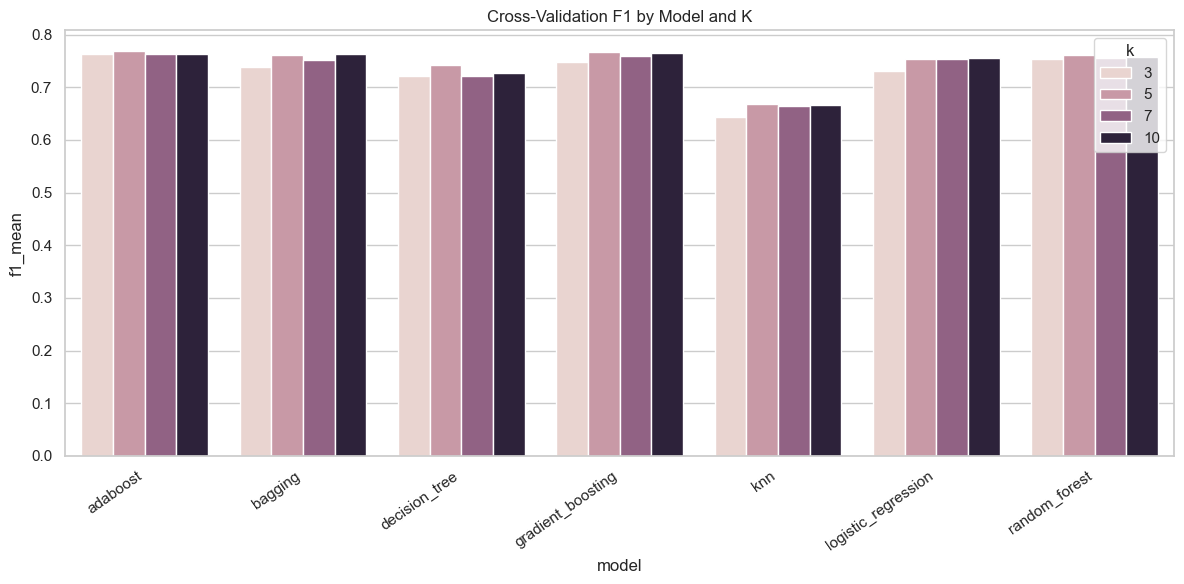

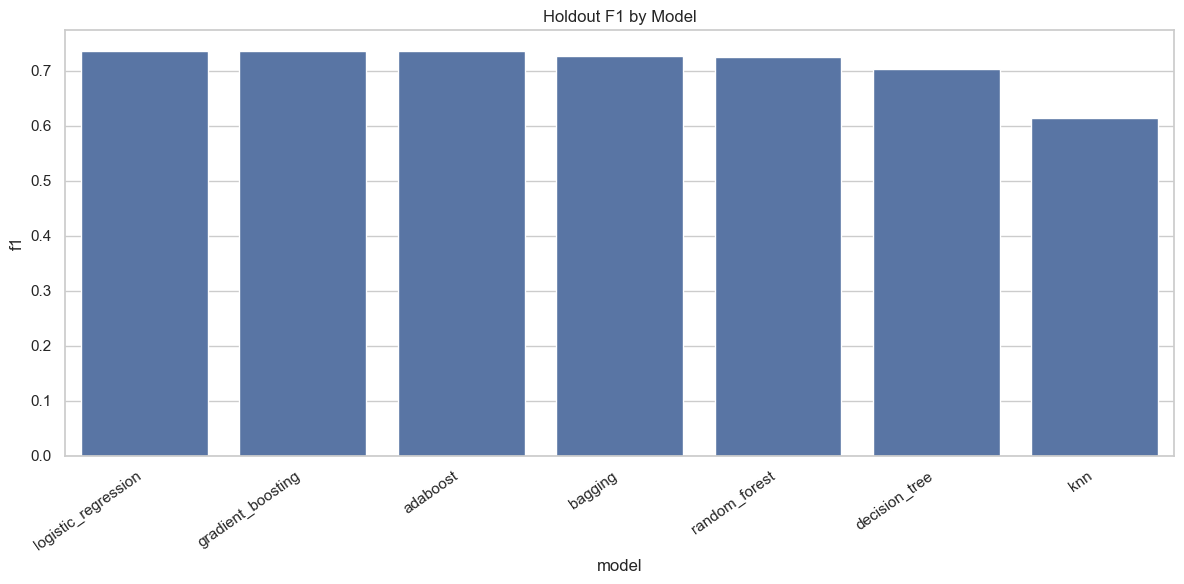


Top 15 features for logistic_regression
              model                       feature  importance_mean  importance_std
logistic_regression          work_interfere_Never         0.061431        0.011804
logistic_regression                 coworkers_Yes         0.021363        0.007714
logistic_regression                 supervisor_No         0.016485        0.008684
logistic_regression              care_options_Yes         0.014670        0.006144
logistic_regression          work_interfere_Often         0.012777        0.012726
logistic_regression                supervisor_Yes         0.011621        0.007963
logistic_regression              Continent_Europe         0.009275        0.007675
logistic_regression      leave_Somewhat difficult         0.008640        0.004041
logistic_regression              leave_Don't know         0.007722        0.002957
logistic_regression           wellness_program_No         0.007567        0.005634
logistic_regression mental_health_consequence_

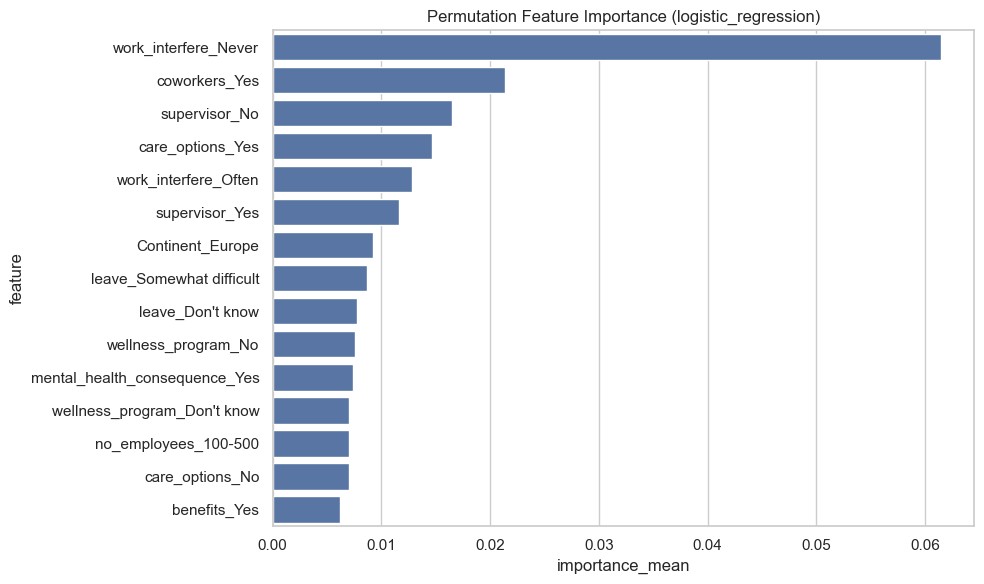


Top 15 features for knn
model                       feature  importance_mean  importance_std
  knn            family_history_Yes         0.040204        0.015024
  knn             family_history_No         0.036825        0.014328
  knn          work_interfere_Never         0.010098        0.009735
  knn         work_interfere_Rarely         0.007465        0.009926
  knn          work_interfere_Often         0.006176        0.004969
  knn                  benefits_Yes         0.005940        0.006504
  knn          leave_Very difficult         0.004239        0.002993
  knn                remote_work_No         0.003660        0.009072
  knn      work_interfere_Sometimes         0.003151        0.009808
  knn mental_health_interview_Maybe         0.002100        0.007382
  knn                   Gender_Male         0.001483        0.009391
  knn              self_employed_No         0.000968        0.004953
  knn             self_employed_Yes         0.000968        0.004953
  knn    

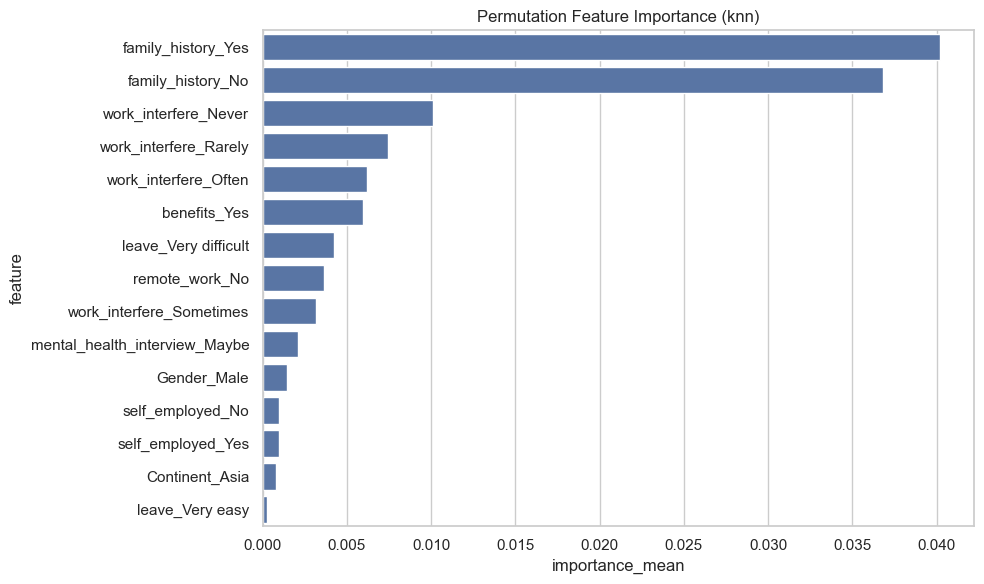


Top 15 features for decision_tree
        model                         feature  importance_mean  importance_std
decision_tree                care_options_Yes         0.073523        0.019675
decision_tree            work_interfere_Never         0.059196        0.015527
decision_tree               family_history_No         0.020810        0.011941
decision_tree        leave_Somewhat difficult         0.020420        0.007276
decision_tree            work_interfere_Often         0.017396        0.010548
decision_tree             benefits_Don't know         0.015222        0.004756
decision_tree                             Age         0.009503        0.003887
decision_tree                  remote_work_No         0.006672        0.006643
decision_tree mental_health_consequence_Maybe         0.003296        0.004876
decision_tree                     benefits_No         0.002905        0.012759
decision_tree                   Gender_Female         0.001098        0.001418
decision_tree    

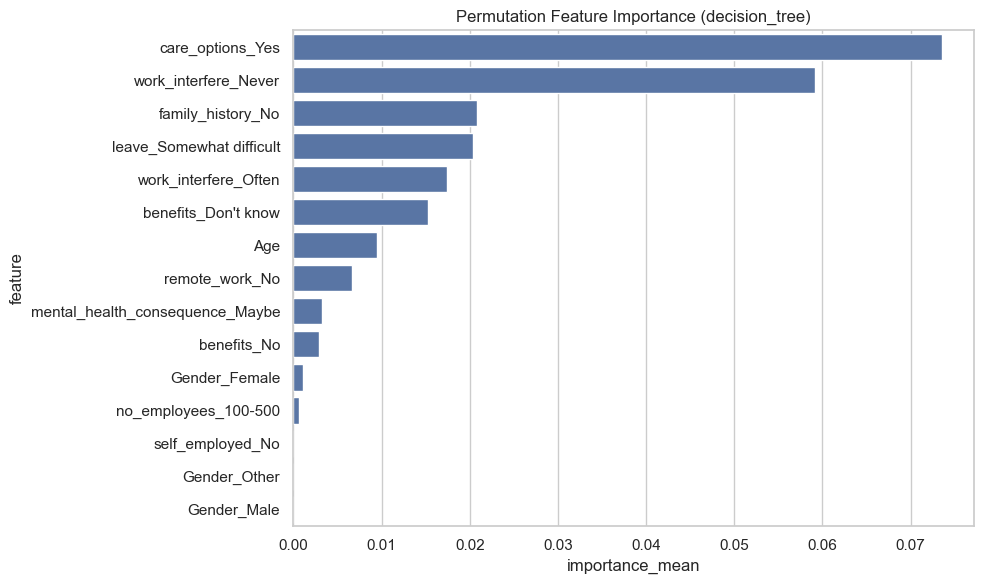


Top 15 features for random_forest
        model                       feature  importance_mean  importance_std
random_forest          work_interfere_Never         0.033825        0.013584
random_forest          work_interfere_Often         0.007999        0.009455
random_forest            obs_consequence_No         0.007476        0.004037
random_forest    phys_health_consequence_No         0.006938        0.003903
random_forest           benefits_Don't know         0.005778        0.005147
random_forest             self_employed_Yes         0.005448        0.003328
random_forest mental_health_consequence_Yes         0.004050        0.005364
random_forest                  seek_help_No         0.003869        0.002234
random_forest                  Gender_Other         0.003869        0.002234
random_forest                Continent_Asia         0.003559        0.001703
random_forest mental_health_interview_Maybe         0.003503        0.002232
random_forest               leave_Very ea

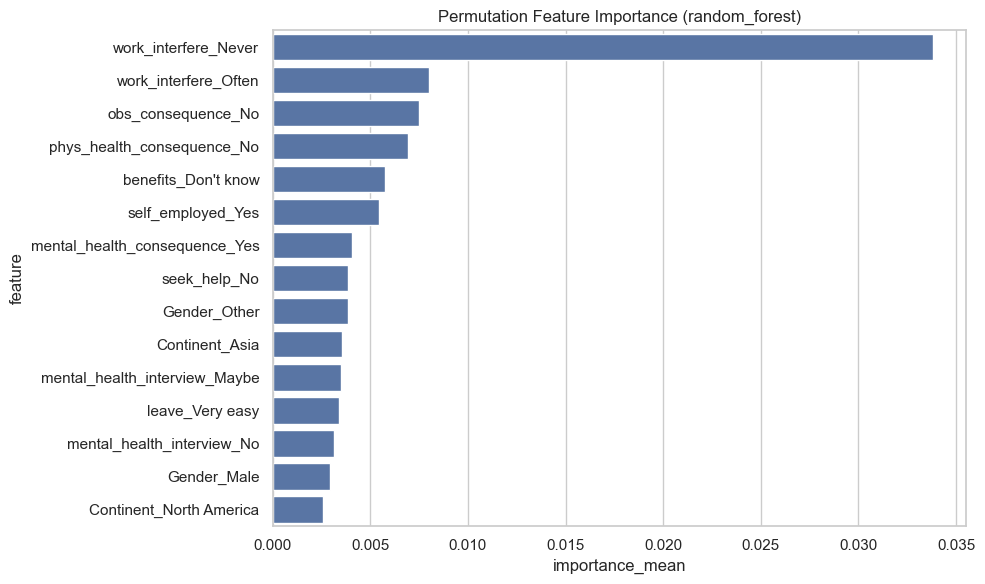


Top 15 features for adaboost
   model                      feature  importance_mean  importance_std
adaboost         work_interfere_Never         0.049617        0.017213
adaboost           family_history_Yes         0.044140        0.014564
adaboost         work_interfere_Often         0.016463        0.013823
adaboost         leave_Very difficult         0.010056        0.004509
adaboost mental_health_consequence_No         0.009453        0.012455
adaboost                          Age         0.005067        0.003204
adaboost           obs_consequence_No         0.004672        0.010191
adaboost             care_options_Yes         0.004591        0.010415
adaboost                  Gender_Male         0.004541        0.005661
adaboost        work_interfere_Rarely         0.003865        0.006480
adaboost         anonymity_Don't know         0.003182        0.004575
adaboost                 coworkers_No         0.002427        0.006048
adaboost                 benefits_Yes         0

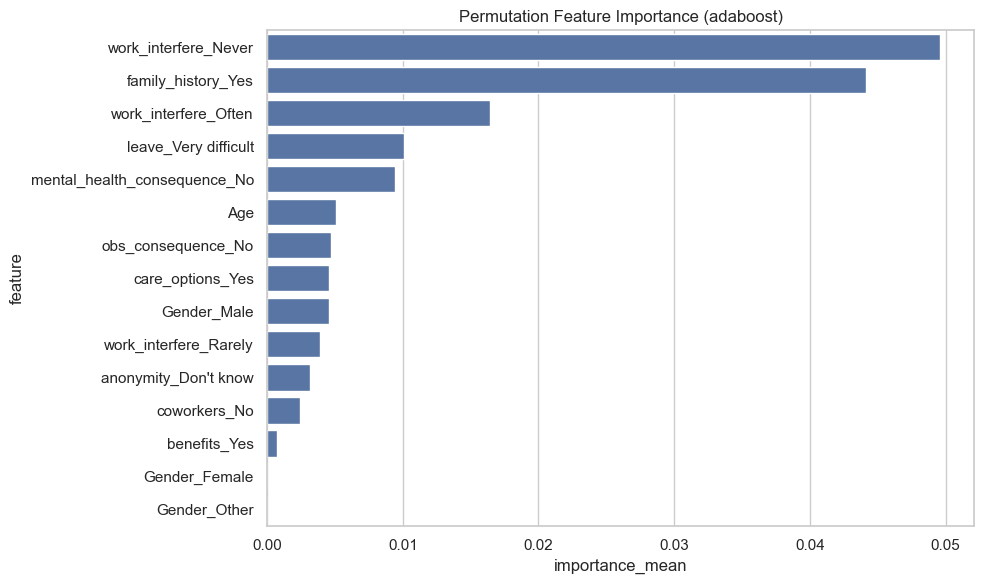


Top 15 features for gradient_boosting
            model                      feature  importance_mean  importance_std
gradient_boosting         work_interfere_Never         0.098302        0.013689
gradient_boosting             care_options_Yes         0.015381        0.014537
gradient_boosting                coworkers_Yes         0.012476        0.004912
gradient_boosting          obs_consequence_Yes         0.011287        0.005556
gradient_boosting         work_interfere_Often         0.010485        0.008663
gradient_boosting                 coworkers_No         0.008236        0.008392
gradient_boosting        care_options_Not sure         0.005885        0.004329
gradient_boosting mental_health_consequence_No         0.004623        0.010690
gradient_boosting                 benefits_Yes         0.004331        0.008786
gradient_boosting         leave_Very difficult         0.004056        0.003910
gradient_boosting      Continent_North America         0.002848        0.005254
g

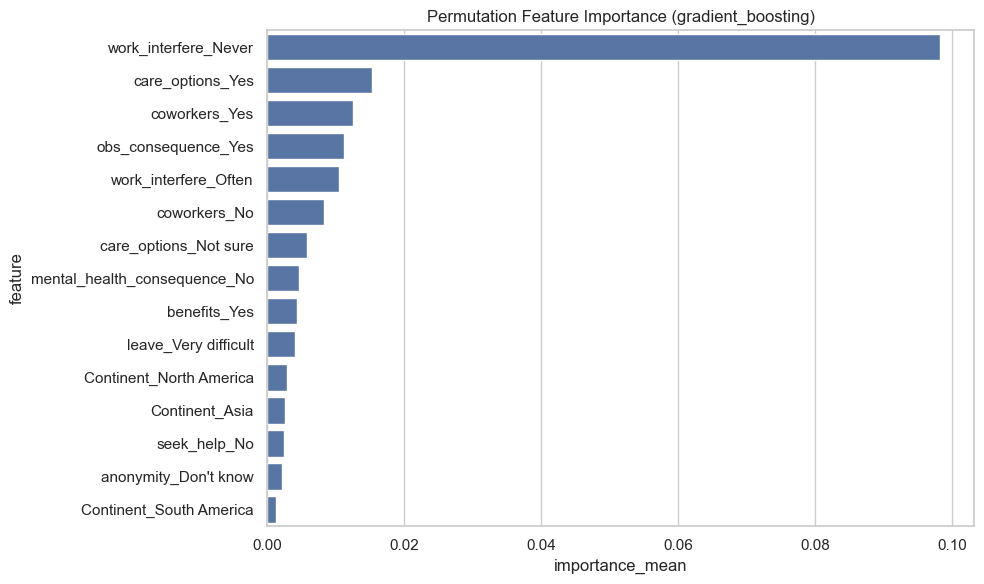


Top 15 features for bagging
  model                         feature  importance_mean  importance_std
bagging            work_interfere_Never         0.069147        0.016194
bagging                care_options_Yes         0.051889        0.018508
bagging            work_interfere_Often         0.033947        0.008416
bagging        leave_Somewhat difficult         0.022378        0.005581
bagging                    coworkers_No         0.014262        0.008414
bagging                    benefits_Yes         0.012010        0.004886
bagging      mental_health_interview_No         0.007563        0.002730
bagging            leave_Very difficult         0.007077        0.005664
bagging                     Gender_Male         0.006276        0.001352
bagging              obs_consequence_No         0.005782        0.002195
bagging             obs_consequence_Yes         0.005757        0.003077
bagging   mental_health_consequence_Yes         0.005526        0.003010
bagging               

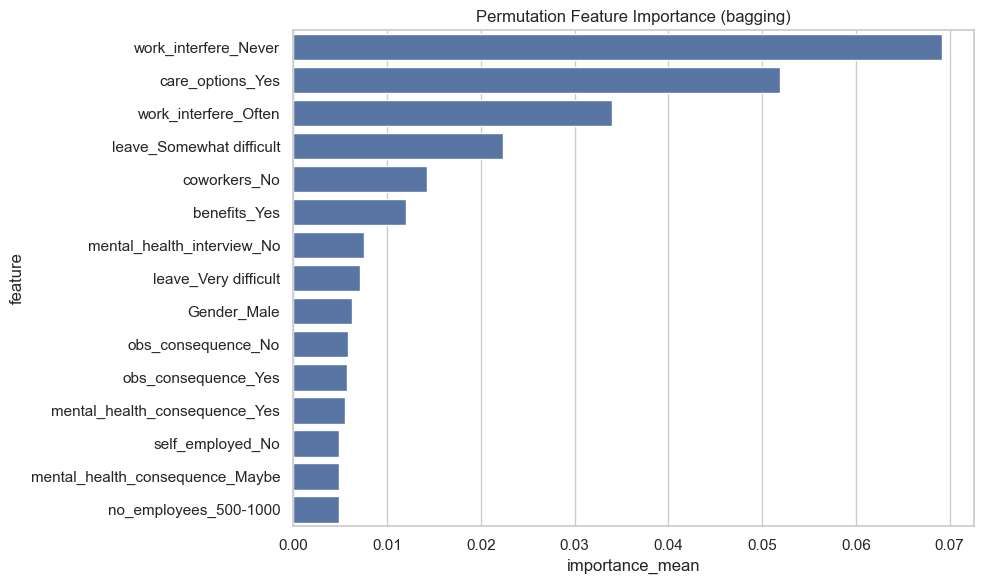


Feature importance consensus
model                            adaboost   bagging  decision_tree  gradient_boosting       knn  logistic_regression  random_forest  avg_importance
feature                                                                                                                                            
work_interfere_Never             0.049617  0.069147       0.059196           0.098302  0.010098             0.061431       0.033825        0.054517
care_options_Yes                 0.004591  0.051889       0.073523           0.015381  0.000000             0.014670       0.000000        0.022865
work_interfere_Often             0.016463  0.033947       0.017396           0.010485  0.006176             0.012777       0.007999        0.015035
family_history_Yes               0.044140  0.000000       0.000000           0.000000  0.040204             0.000000       0.000000        0.012049
family_history_No                0.000000  0.000000       0.020810           0.000

In [17]:
# Main run
artifacts = run_training_pipeline(
    csv_path="dataset/survey.csv",
    target_col="treatment",
    k_values=(3, 5, 7, 10),
    primary_metric="f1",
    tune_hyperparameters=True,
)

plot_model_performance(artifacts)
feature_df = export_feature_importance(artifacts, top_n=15)

print("=== Holdout Results (Top 5 by F1) ===")
print(artifacts["holdout_df"].head(5).to_string(index=False))
print("\nTables and plots are shown in this notebook.")


# 결과 해석

## 모델 성능

최종 holdout test 결과에서 Logistic Regression과 Gradient Boosting의 F1 score가 모두 약 `0.737`로 가장 높았다. 두 모델의 ROC-AUC도 각각 약 `0.824`, `0.824`로 비슷하게 나타나 치료 여부를 구분하는 성능이 가장 안정적인 축에 속했다.

AdaBoost는 F1 score가 약 `0.736`으로 상위권이었고 accuracy는 약 `0.746`, precision은 약 `0.781`로 가장 높았다. 다만 recall은 약 `0.695`로 Logistic Regression과 Gradient Boosting보다 낮아 실제 치료 경험이 있는 응답자를 일부 더 놓칠 수 있다.

교차 검증 결과에서는 ensemble 계열 모델의 성능이 전반적으로 높았다. 5-fold 기준 AdaBoost의 평균 F1 score는 약 `0.769`, Gradient Boosting은 약 `0.766`, Random Forest는 약 `0.761`이었다. 반면 KNN은 holdout F1 score가 약 `0.614`이고 recall도 약 `0.516`으로 낮아, 이 데이터에서는 상위 모델보다 분류 성능이 떨어졌다.

## 피처 중요도

모델별 피처 중요도는 permutation feature importance로 계산했다. 특정 피처 값을 섞었을 때 F1 score가 얼마나 감소하는지를 보므로, 값이 클수록 해당 모델의 예측에 더 크게 기여한 피처로 해석할 수 있다.

모델 전체 요약에서 `work_interfere_Never`가 평균 중요도 약 `0.055`로 가장 높았다. 그 다음은 `care_options_Yes` 약 `0.023`, `work_interfere_Often` 약 `0.015` 순서였다. `family_history_Yes`와 `family_history_No`도 일부 모델에서 높은 중요도를 보였다.

따라서 현재 결과는 정신 건강 문제가 업무에 얼마나 방해되는지에 대한 응답(`work_interfere`)과 치료 지원 선택지를 알고 있거나 이용할 수 있는지(`care_options`)가 치료 여부 예측에서 중요한 신호임을 보여준다.

In [ ]:
# 하이퍼 파라미터 없이 학습
# artifacts_quick = run_training_pipeline(
#     csv_path="dataset/survey.csv",
#     target_col="treatment",
#     k_values=(3, 5),
#     primary_metric="f1",
#     tune_hyperparameters=False,
# )
